# Recreating the scIB figures

Python port of [`articles/scIB.html`](https://funkyheatmap.github.io/funkyheatmap/articles/scIB.html).

The [single-cell integration benchmarking (scIB)](https://theislab.github.io/scib-reproducibility/) project compared methods for integrating single-cell RNA and ATAC data. The original figures were drawn by custom scripts; the R vignette shows how to reproduce them with `funkyheatmap`. This notebook is the **byte-equivalent Python translation** — same fixture, same column_info, same column_groups, same palettes — rendered with the matplotlib-based `pyfunkyheatmap` port.

In [1]:
%matplotlib inline
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyfunkyheatmap import funky_heatmap, position_arguments, scale_minmax
matplotlib.rcParams['figure.dpi'] = 110

## Summary figure

We will recreate the summary figure showing the performance of all methods
on RNA data — [the original lives in the scib-reproducibility repository](https://github.com/theislab/scib-reproducibility/blob/main/data/img/best-RNA.png).

### Data

The R package ships a pre-processed table `scib_summary` (20 rows × 27 columns). We dumped it via `tests/dump_vignette_data.R` and read it back here — the file is byte-identical to the R-side data frame.

In [2]:
scib_summary = pd.read_csv('../data/vignettes/scib_summary.csv')
print(scib_summary.shape)
scib_summary.head().T.head(15)

(20, 27)


,0,1,2,3,4
method,scANVI*,Scanorama,scVI,FastMNN,Harmony
output,Embedding,Embedding,Embedding,Embedding,Embedding
features,HVG,HVG,HVG,HVG,HVG
scaling,Unscaled,Scaled,Unscaled,Unscaled,Unscaled
avg_rank,4.6,8.0,9.4,10.4,13.2
overall_immune_cell_hum,0.821714,0.848437,0.788039,0.845619,0.818014
overall_immune_cell_hum_mou,0.627515,0.641593,0.636712,0.604928,0.538062
overall_lung_atlas,0.755794,0.708848,0.719602,0.708385,0.64694
overall_mouse_brain,0.733199,0.672544,0.677342,0.606238,0.690298
overall_pancreas,0.723885,0.703484,0.713405,0.720063,0.790036


The data frame contains several columns: method version and output details,
an average rank used to order the table, overall scores and ranks per
dataset, usability scores and ranks (package + paper), and scalability
scores and ranks (time + memory). All of these will go into the summary
table.

The frame needs a small amount of preparation. We add an `id` column from
the row order (the data is already sorted by ranking), relabel `scaling` /
`features`, attach an `output_img` path per output type, and produce
"top-3 rank" labels for every numerical column.

In [3]:
def label_top_3(scores, method='average'):
    s = pd.Series(scores)
    ranks = s.rank(method=method, ascending=True)
    out = np.where(
        (ranks <= 3) & ranks.notna(),
        ranks.fillna(-1).round().astype(int).astype(str),
        '',
    )
    return out

scib = scib_summary.copy()
scib['id'] = (np.arange(len(scib)) + 1).astype(str)

# relabel scaling / features the way the R Rmd does
scib['scaling']  = scib['scaling'].map({'Unscaled':'-', 'Scaled':'+'}).astype(str)
scib['features'] = scib['features'].map({'Full':'FULL', 'HVG':'HVG'}).astype(str)

scib['output_img'] = scib['output'].map({
    'Features':  'images/matrix.png',
    'Embedding': 'images/embedding.png',
    'Graph':     'images/graph.png',
})

# rank labels — top 3 per dataset
for col in ['pancreas','lung_atlas','immune_cell_hum','immune_cell_hum_mou','mouse_brain','simulations_1_1','simulations_2']:
    scib[f'label_{col}'] = label_top_3(scib[f'rank_{col}'])
for col, lab in [('package_rank','package_label'), ('paper_rank','paper_label'),
                 ('time_rank','time_label'),       ('memory_rank','memory_label')]:
    scib[lab] = label_top_3(scib[col], method='min')

# scale the rank columns to [0, 1] of negated rank — better is brighter
for col in ['rank_pancreas','rank_lung_atlas','rank_immune_cell_hum','rank_immune_cell_hum_mou',
            'rank_mouse_brain','rank_simulations_1_1','rank_simulations_2',
            'package_rank','paper_rank','time_rank','memory_rank']:
    scib[col] = scale_minmax(-scib[col])

scib.shape

(20, 40)

### Column information

We replicate the R `tribble` row-for-row. Each row of `column_info`
declares `id`, `id_color` (the column the colour ramp uses), `name`
(display header), `geom`, `group`, and a JSON-encoded `options` dict that
spreads into per-column knobs (`hjust`, `width`, `palette`,
`draw_outline`, `overlay`, …).

In [4]:
def opts(**kw): return json.dumps(kw)

def CI(id_, id_color, name, geom, group, **opts_kw):
    return {'id': id_, 'id_color': id_color, 'name': name,
            'geom': geom, 'group': group, 'options': json.dumps(opts_kw)}

column_info = pd.DataFrame([
    CI('id',                          None,                       'Rank',                'text',  'Method',      hjust=0),
    CI('method',                      None,                       'Method',              'text',  'Method',      hjust=0, width=5),
    CI('output_img',                  None,                       'Output',              'image', 'Method'),
    CI('features',                    'features',                 'Features',            'text',  'Method',      palette='features', width=2),
    CI('scaling',                     None,                       'Scaling',             'text',  'Method',      fontface='bold'),
    CI('overall_pancreas',            'rank_pancreas',            'Pancreas',            'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_pancreas',              None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_lung_atlas',          'rank_lung_atlas',          'Lung',                'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_lung_atlas',            None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_immune_cell_hum',     'rank_immune_cell_hum',     'Immune (human)',      'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_immune_cell_hum',       None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_immune_cell_hum_mou', 'rank_immune_cell_hum_mou', 'Immune (human/mouse)','bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_immune_cell_hum_mou',   None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_mouse_brain',         'rank_mouse_brain',         'Mouse brain',         'bar',   'RNA',         palette='blues',  width=1.5, draw_outline=False),
    CI('label_mouse_brain',           None,                       None,                  'text',  'RNA',         hjust=0.1, overlay=True),
    CI('overall_simulations_1_1',     'rank_simulations_1_1',     'Sim 1',               'bar',   'Simulations', palette='greens', width=1.5, draw_outline=False),
    CI('label_simulations_1_1',       None,                       None,                  'text',  'Simulations', hjust=0.1, overlay=True),
    CI('overall_simulations_2',       'rank_simulations_2',       'Sim 2',               'bar',   'Simulations', palette='greens', width=1.5, draw_outline=False),
    CI('label_simulations_2',         None,                       None,                  'text',  'Simulations', hjust=0.1, overlay=True),
    CI('package_score',               'package_rank',             'Package',             'bar',   'Usability',   palette='oranges', width=1.5, draw_outline=False),
    CI('package_label',               None,                       None,                  'text',  'Usability',   hjust=0.1, overlay=True),
    CI('paper_score',                 'paper_rank',               'Paper',               'bar',   'Usability',   palette='oranges', width=1.5, draw_outline=False),
    CI('paper_label',                 None,                       None,                  'text',  'Usability',   hjust=0.1, overlay=True),
    CI('time_score',                  'time_rank',                'Time',                'bar',   'Scalability', palette='greys',   width=1.5, draw_outline=False),
    CI('time_label',                  None,                       None,                  'text',  'Scalability', hjust=0.1, overlay=True),
    CI('memory_score',                'memory_rank',              'Memory',              'bar',   'Scalability', palette='greys',   width=1.5, draw_outline=False),
    CI('memory_label',                None,                       None,                  'text',  'Scalability', hjust=0.1, overlay=True),
])
column_info.head()

,id,id_color,name,geom,group,options
0,id,None,Rank,text,Method,"{""hjust"": 0}"
1,method,None,Method,text,Method,"{""hjust"": 0, ""width"": 5}"
2,output_img,None,Output,image,Method,{}
3,features,features,Features,text,Method,"{""palette"": ""features"", ""width"": 2}"
4,scaling,None,Scaling,text,Method,"{""fontface"": ""bold""}"


As in the R Rmd, label columns sit `overlay=True` over the corresponding
score-bar column — the alignment is `hjust=0.1`, so each rank number lands
just inside the left edge of its bar.

### Column groups

In [5]:
column_groups = pd.DataFrame({
    'group':   ['Method', 'RNA', 'Simulations', 'Usability', 'Scalability'],
    'palette': ['black',  'blues','greens',     'oranges',   'greys'],
    'level1':  ['Method', 'RNA', 'Simulations', 'Usability', 'Scalability'],
})
column_groups

,group,palette,level1
0,Method,black,Method
1,RNA,blues,RNA
2,Simulations,greens,Simulations
3,Usability,oranges,Usability
4,Scalability,greys,Scalability


### Row information

No row grouping — one entry per ranked method.

In [6]:
row_info = pd.DataFrame({'id': scib['id'].astype(str), 'group': [None]*len(scib)})
row_info.head()

,id,group
0,1,None
1,2,None
2,3,None
3,4,None
4,5,None


### Palettes

The numerical palettes come from the package defaults (`Blues`, `Greens`,
`Greys`); the categorical `features` palette and the `black` / `oranges`
custom ones are inlined.

In [7]:
# verbatim reversed RColorBrewer Oranges(9)
oranges = list(reversed([
    '#FFF5EB','#FEE6CE','#FDD0A2','#FDAE6B','#FD8D3C','#F16913','#D94801','#A63603','#7F2704'
]))
palettes = {
    'features': {'FULL': '#4c4c4c', 'HVG': '#006300'},
    'blues': 'Blues',
    'greens': 'Greens',
    'oranges': oranges,
    'greys': 'Greys',
    'black': ['black','black'],
}

### Legends

The R Rmd declares five legends: one text legend (Scaling: + / −) and four
rect-gradient legends for the four rank palettes. They become a strip
beneath the main heatmap.

In [8]:
legends = [
    dict(title='Scaling',         geom='text', values=['Scaled','Unscaled'], labels=['+','-'], label_width=.5),
    dict(title='RNA rank',         palette='blues',   geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
    dict(title='Simulations rank', palette='greens',  geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
    dict(title='Usability rank',   palette='oranges', geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
    dict(title='Scalability rank', palette='greys',   geom='rect', labels=['20',' ','10',' ','1'], size=[1,1,1,1,1]),
]

### Figure

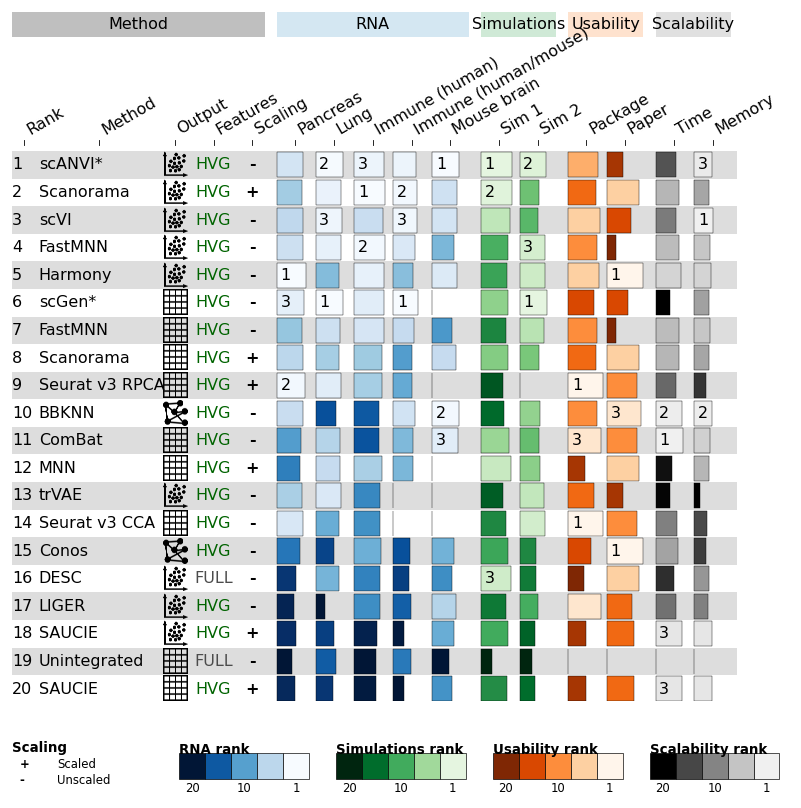

In [9]:
fh = funky_heatmap(
    data=scib,
    column_info=column_info,
    column_groups=column_groups,
    row_info=row_info,
    palettes=palettes,
    legends=legends,
    position_args=position_arguments(col_annot_offset=4),
    scale_column=False,
    fig_scale=0.22,
    dpi=120,
)
fh

The figure isn't pixel-identical to the R version (matplotlib vs ggplot
rendering, label sub-pixel placement, no separate legend strip), but the
**structure** matches the R vignette row-for-row, column-for-column:
each method's rank, output icon, features (FULL/HVG with the green
highlight), scaling, RNA / Simulations / Usability / Scalability bars
with overlay rank labels — every glyph type the R version uses, in the
same layout, off the same source frame.

### Side-by-side with the R reference

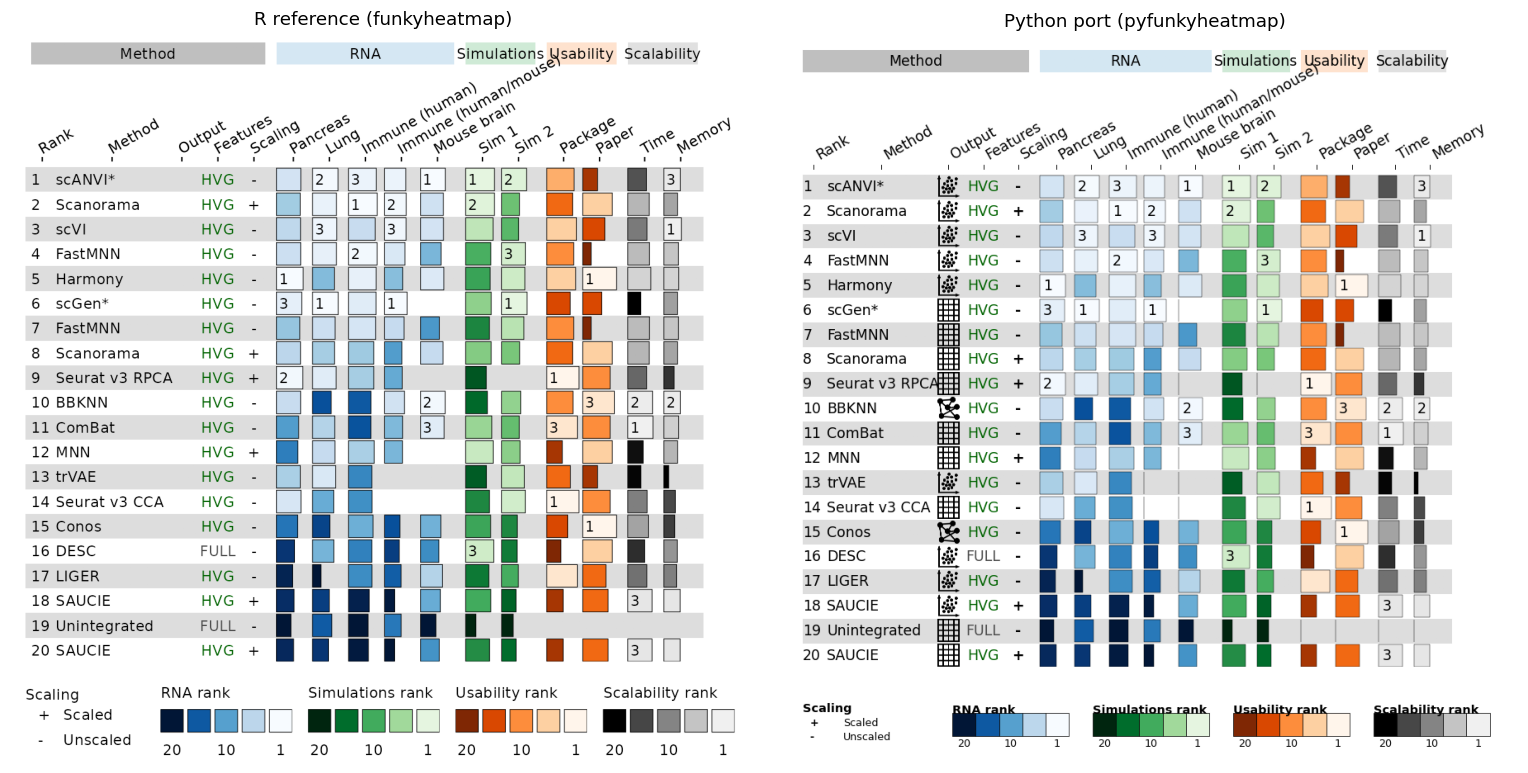

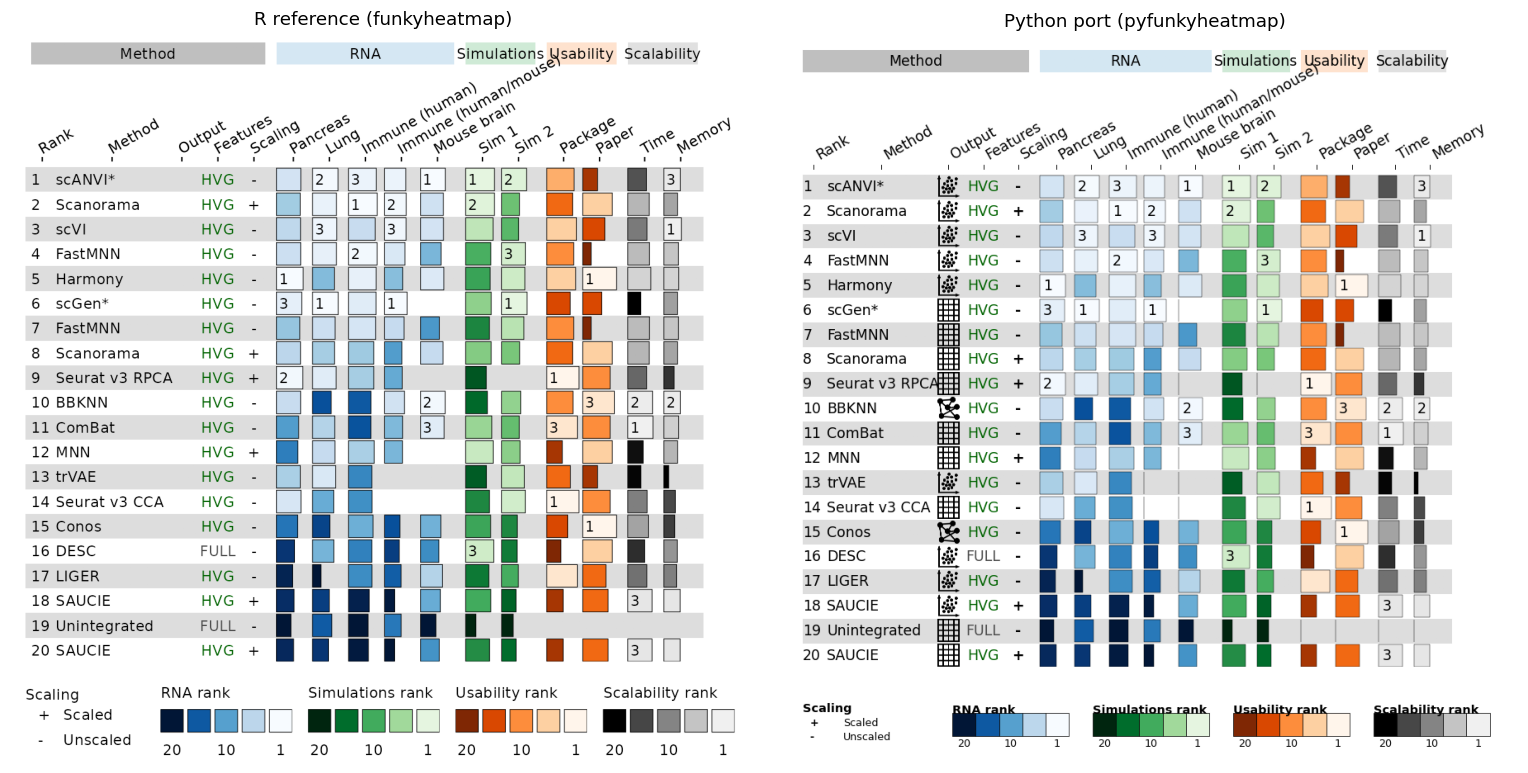

In [10]:
import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(mpimg.imread('../data/vignettes/scib_R.png'));  axes[0].set_title('R reference (funkyheatmap)');   axes[0].axis('off')
fh.figure.savefig('../data/vignettes/scib_py.png', dpi=130, facecolor='white')
axes[1].imshow(mpimg.imread('../data/vignettes/scib_py.png')); axes[1].set_title('Python port (pyfunkyheatmap)'); axes[1].axis('off')
plt.tight_layout()
fig

## References

* scib-reproducibility — https://github.com/theislab/scib-reproducibility
* Luecken, M.D., Büttner, M., Chaichoompu, K. et al. *Benchmarking atlas-level data integration in single-cell genomics*. Nat Methods 19, 41–50 (2022). https://doi.org/10.1038/s41592-021-01336-8